<div style="
text-align:center;
background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
<h1 style="margin-bottom:8px;">
IBM HR Analytics
</h1>
<h2 style="font-weight:normal;">
Employee Attrition & Performance Analysis 📊
</h2>
<p style="font-size:16px; margin-top:10px;">
Data Science & Machine Learning Project
</p>
</div>

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Importing Libraries

</h2>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from tabulate import tabulate

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Loading Dataset

</h2>

In [2]:
ibm = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [3]:
ibm.head()

,ï»¿Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
ibm.tail()

,ï»¿Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Checking Shape and Column

</h2>

In [5]:
ibm.shape

(1470, 35)

In [6]:
ibm.columns

Index(['ï»¿Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [7]:
ibm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   ï»¿Age                    1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [8]:
ibm.describe(include='number')

,ï»¿Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [9]:
ibm.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [10]:
ibm.isna().sum()

ï»¿Age                      0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">Data Visualization

<Figure size 800x500 with 0 Axes>

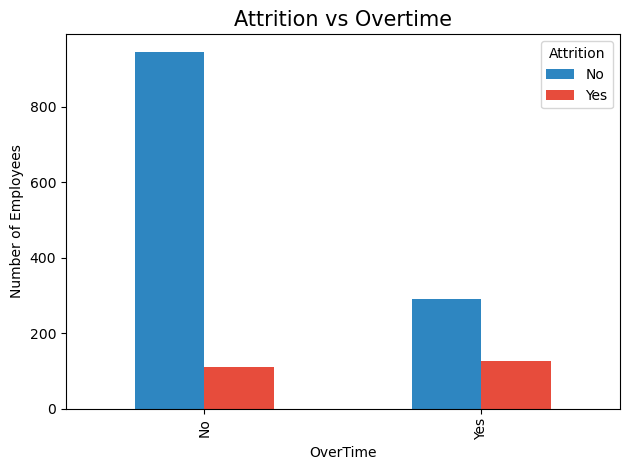

In [11]:
pivot_ot = ibm.groupby(['OverTime','Attrition']).size().unstack()

plt.figure(figsize=(8,5))
pivot_ot.plot(kind='bar',
              color=['#2E86C1', '#E74C3C'])

plt.title("Attrition vs Overtime", fontsize=15)
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

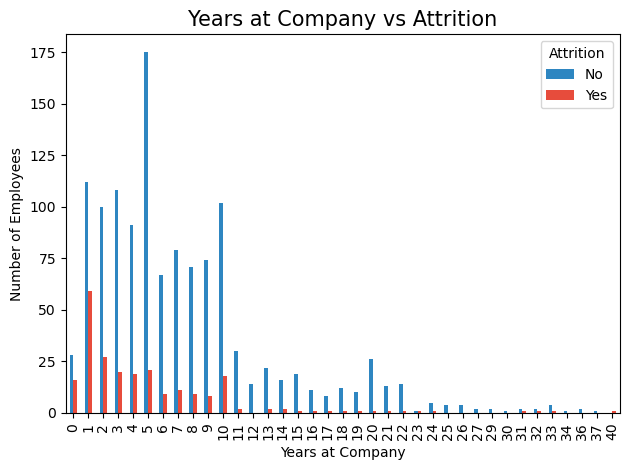

In [12]:
years_attr = ibm.groupby(['YearsAtCompany','Attrition']).size().unstack()

plt.figure(figsize=(8,5))
years_attr.plot(kind='bar',
                color=['#2E86C1', '#E74C3C'])

plt.title("Years at Company vs Attrition", fontsize=15)
plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.show()


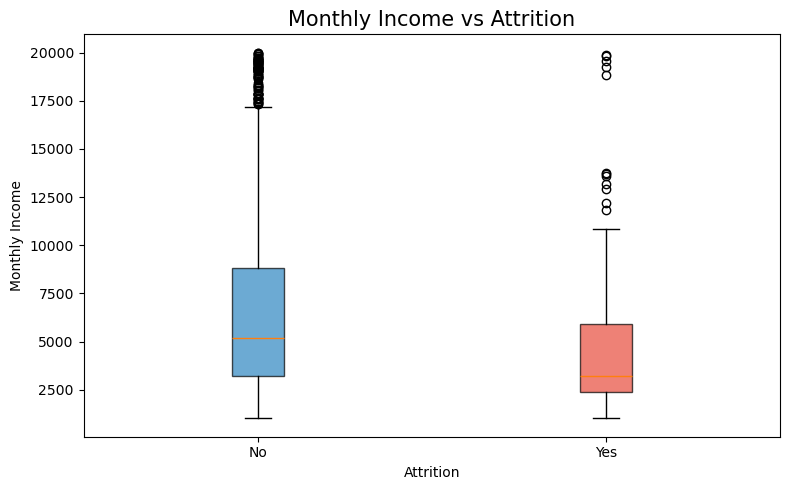

In [13]:
plt.figure(figsize=(8,5))

box = plt.boxplot([
    ibm[ibm['Attrition']=='No']['MonthlyIncome'],
    ibm[ibm['Attrition']=='Yes']['MonthlyIncome']
], patch_artist=True)

colors = ['#2E86C1', '#E74C3C']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title("Monthly Income vs Attrition", fontsize=15)
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.xticks([1,2], ['No','Yes'])

plt.tight_layout()
plt.show()

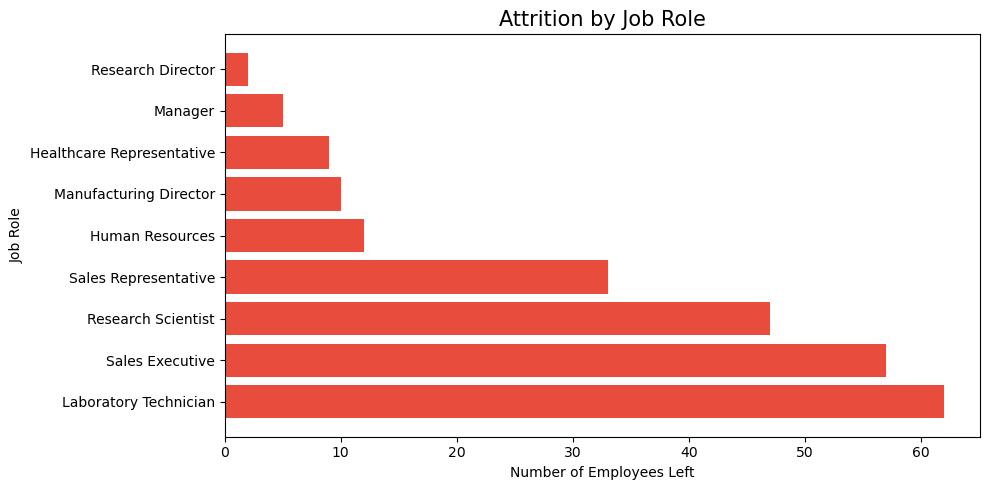

In [14]:
job_attr = ibm[ibm['Attrition']=='Yes']['JobRole'].value_counts()
plt.figure(figsize=(10,5))
plt.barh(job_attr.index, job_attr.values, color='#E74C3C')
plt.title("Attrition by Job Role", fontsize=15)
plt.xlabel("Number of Employees Left")
plt.ylabel("Job Role")
plt.tight_layout()
plt.show()

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Encoding


In [15]:
cat_cols = ibm.select_dtypes(include='object').columns
ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded = ohe.fit_transform(ibm[cat_cols])
encoded_ibm = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cat_cols))
ibm = ibm.drop(cat_cols, axis=1)
ibm = pd.concat([ibm, encoded_ibm], axis=1)

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Scaling

</h2>

In [16]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(ibm)
scaled_data

array([[ 0.4463504 ,  0.74252653, -1.01090934, ..., -0.91892141,
         1.45864991,  1.59174553],
       [ 1.32236521, -1.2977746 , -0.14714972, ...,  1.08823234,
        -0.68556546, -0.62824112],
       [ 0.008343  ,  1.41436324, -0.88751511, ..., -0.91892141,
         1.45864991,  1.59174553],
       ...,
       [-1.08667552, -1.60518328, -0.64072665, ...,  1.08823234,
        -0.68556546,  1.59174553],
       [ 1.32236521,  0.54667746, -0.88751511, ...,  1.08823234,
        -0.68556546, -0.62824112],
       [-0.32016256, -0.43256792, -0.14714972, ...,  1.08823234,
        -0.68556546, -0.62824112]], shape=(1470, 48))

In [17]:
X = scaled_data
X

array([[ 0.4463504 ,  0.74252653, -1.01090934, ..., -0.91892141,
         1.45864991,  1.59174553],
       [ 1.32236521, -1.2977746 , -0.14714972, ...,  1.08823234,
        -0.68556546, -0.62824112],
       [ 0.008343  ,  1.41436324, -0.88751511, ..., -0.91892141,
         1.45864991,  1.59174553],
       ...,
       [-1.08667552, -1.60518328, -0.64072665, ...,  1.08823234,
        -0.68556546,  1.59174553],
       [ 1.32236521,  0.54667746, -0.88751511, ...,  1.08823234,
        -0.68556546, -0.62824112],
       [-0.32016256, -0.43256792, -0.14714972, ...,  1.08823234,
        -0.68556546, -0.62824112]], shape=(1470, 48))

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
PCA

</h2>

In [18]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)
X_reduced

array([[-0.30606304,  2.46127688],
       [ 0.17271936, -1.63364173],
       [-3.08513978, -0.85523647],
       ...,
       [-0.9583079 , -1.34147454],
       [ 1.26713823,  1.99807576],
       [-1.35878224, -1.18463441]], shape=(1470, 2))

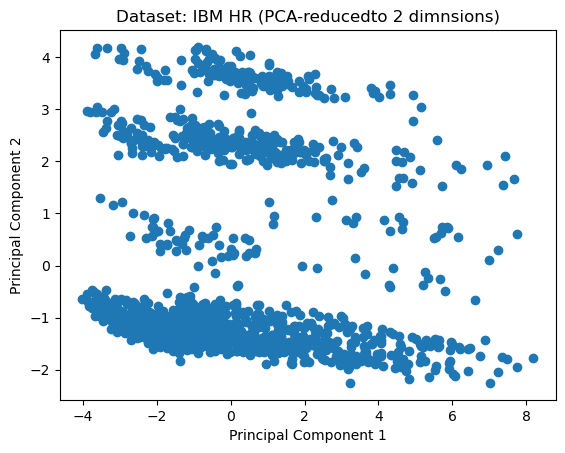

In [19]:
plt.scatter(X_reduced[:, 0], X_reduced[:, 1])
plt.title("Dataset: IBM HR (PCA-reducedto 2 dimnsions)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
KMeans

</h2>

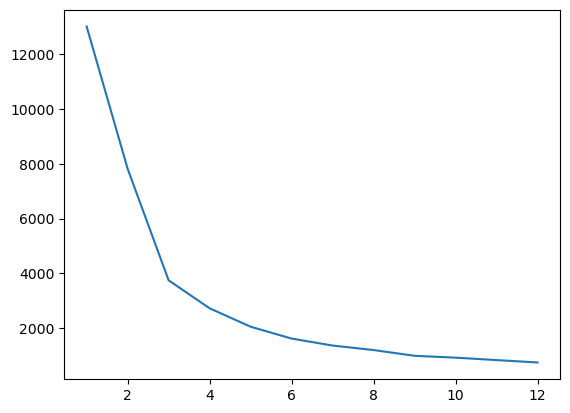

In [20]:
wcss=[]
for i in range(1,13):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(X_reduced)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,13),wcss)
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.show()

In [21]:
kmeans=KMeans(n_clusters=4,init='k-means++',random_state=42)
y_kmeans=kmeans.fit_predict(X_reduced)
y_kmeans

array([1, 3, 0, ..., 0, 1, 0], shape=(1470,), dtype=int32)

In [22]:
score = silhouette_score(X_reduced,y_kmeans)
print("silhouette_score",score)

silhouette_score 0.490378081793152


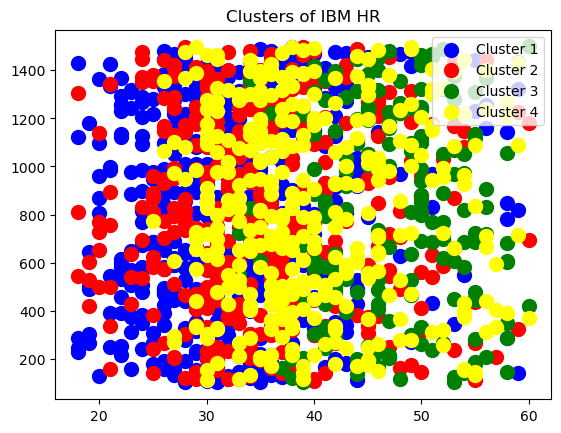

In [23]:
X = ibm.values 

plt.scatter(X[y_kmeans==0, 0], X[y_kmeans==0, 1], s=100, c='blue', label='Cluster 1')
plt.scatter(X[y_kmeans==1, 0], X[y_kmeans==1, 1], s=100, c='red', label='Cluster 2')
plt.scatter(X[y_kmeans==2, 0], X[y_kmeans==2, 1], s=100, c='green', label='Cluster 3')
plt.scatter(X[y_kmeans==3, 0], X[y_kmeans==3, 1], s=100, c='yellow', label='Cluster 4')

plt.title('Clusters of IBM HR')
plt.legend()
plt.show()

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Agglomerative

</h2>

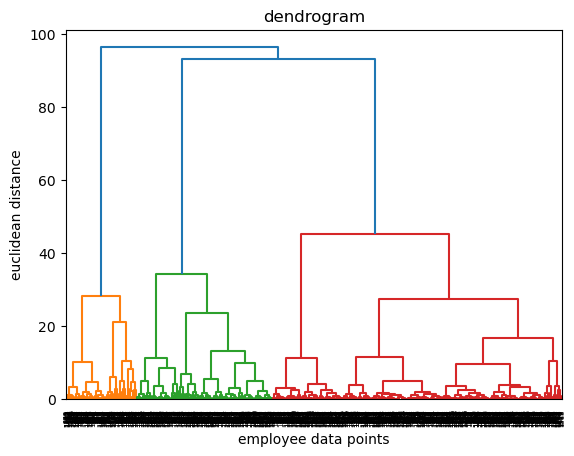

In [24]:
dendrogram=sch.dendrogram(sch.linkage(X_reduced,method='ward'))
plt.title('dendrogram')
plt.xlabel('employee data points')
plt.ylabel('euclidean distance')
plt.show()

In [25]:
ahc=AgglomerativeClustering(n_clusters=3,metric='euclidean',linkage='ward')
y_ahc=ahc.fit_predict(X_reduced)
y_ahc


array([2, 0, 0, ..., 0, 2, 0], shape=(1470,))

In [26]:
sil_ahc=silhouette_score(X_reduced,y_ahc)
sil_ahc

0.5372197761555216

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
DBSCAN

</h2>

In [27]:
epsilon = 0.9
min_samples = 5
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
labels = dbscan.fit_predict(X_reduced)
set(labels)

{np.int64(-1), np.int64(0)}

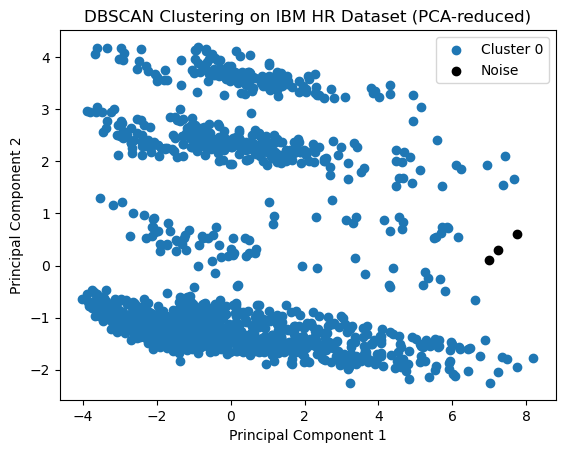

In [28]:
plt.figure()

for label in set(labels):
    if label == -1:
        plt.scatter(
            X_reduced[labels == label, 0],
            X_reduced[labels == label, 1],
            c='black',
            label='Noise'
        )
    else:
        plt.scatter(
            X_reduced[labels == label, 0],
            X_reduced[labels == label, 1],
            label=f'Cluster {label}'
        )

plt.title("DBSCAN Clustering on IBM HR Dataset (PCA-reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

In [29]:
sil_db=silhouette_score(X_reduced,labels)
sil_db

0.46462192871476515

<h2 style="background: linear-gradient(135deg, #141E30, #243B55);
padding:30px;
border-radius:12px;
color:white;
font-family: 'Segoe UI', sans-serif;
box-shadow: 0px 10px 25px rgba(0,0,0,0.3);
">
Mean Shift

</h2>

In [30]:
from sklearn.cluster import MeanShift,estimate_bandwidth
ms = MeanShift()
labels_ms = ms.fit_predict(X_reduced)

In [31]:
ibm['MeanShift_Cluster'] = labels_ms
print("Clusters found:", ibm['MeanShift_Cluster'].nunique())
print(ibm['MeanShift_Cluster'].value_counts())

Clusters found: 2
MeanShift_Cluster
0    996
1    474
Name: count, dtype: int64


In [32]:
score_ms = silhouette_score(X_reduced, labels_ms)
score_ms

0.4608989815539574

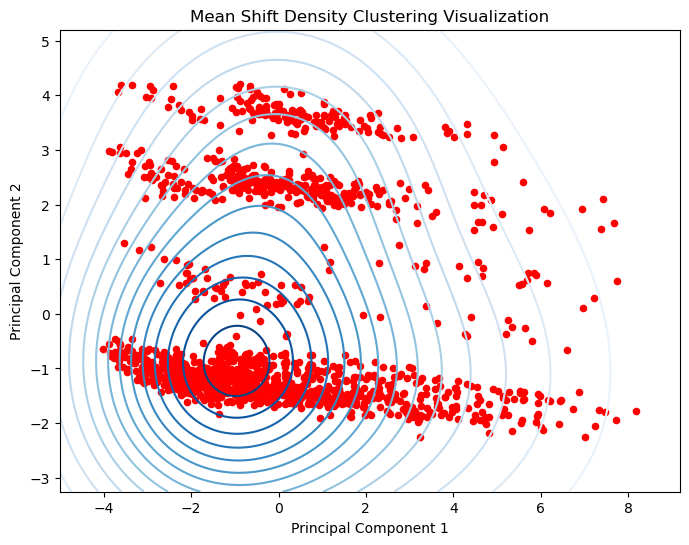

In [33]:
from sklearn.neighbors import KernelDensity

bandwidth = estimate_bandwidth(X_reduced, quantile=0.2)
ms = MeanShift(bandwidth=bandwidth)
labels_ms = ms.fit_predict(X_reduced)

kde = KernelDensity(bandwidth=bandwidth)
kde.fit(X_reduced)

x_min, x_max = X_reduced[:, 0].min() - 1, X_reduced[:, 0].max() + 1
y_min, y_max = X_reduced[:, 1].min() - 1, X_reduced[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid_samples = np.vstack([xx.ravel(), yy.ravel()]).T
density = np.exp(kde.score_samples(grid_samples))
density = density.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contour(xx, yy, density, levels=15, cmap='Blues')

plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c='red', s=20)

plt.title("Mean Shift Density Clustering Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [34]:
table = [['Clustering','Silhouette Score'],
         ['KMean Score',score],['Agglomerative',sil_ahc],
         ['DBSCAN',sil_db],['Mean Shift',score_ms]]
print(tabulate(table,headers='firstrow',tablefmt='fancy_grid'))

╒═══════════════╤════════════════════╕
│ Clustering    │   Silhouette Score │
╞═══════════════╪════════════════════╡
│ KMean Score   │           0.490378 │
├───────────────┼────────────────────┤
│ Agglomerative │           0.53722  │
├───────────────┼────────────────────┤
│ DBSCAN        │           0.464622 │
├───────────────┼────────────────────┤
│ Mean Shift    │           0.460899 │
╘═══════════════╧════════════════════╛


In [35]:
ibm = pd.DataFrame(ibm)
ibm['cluster'] = y_ahc

In [36]:
ibm

,ï»¿Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,MeanShift_Cluster,cluster
0,41,1102,1,2,1,1,2,94,3,2,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1,2
1,49,279,8,1,1,2,3,61,2,2,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,0
2,37,1373,2,2,1,4,4,92,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0,0
3,33,1392,3,4,1,5,4,56,3,1,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0,0
4,27,591,2,1,1,7,1,40,3,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,1,2061,3,41,4,2,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0
1466,39,613,6,1,1,2062,4,42,2,3,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0
1467,27,155,4,3,1,2064,2,87,4,2,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0,0
1468,49,1023,2,3,1,2065,4,63,2,2,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1,2


In [37]:
cluster_0=ibm.loc[ibm['cluster']==0]
cluster_0.head()

,ï»¿Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,MeanShift_Cluster,cluster
1,49,279,8,1,1,2,3,61,2,2,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,0
2,37,1373,2,2,1,4,4,92,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0,0
3,33,1392,3,4,1,5,4,56,3,1,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0,0
4,27,591,2,1,1,7,1,40,3,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0
5,32,1005,2,2,1,8,4,79,3,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0


In [38]:
cluster_0.describe()

,ï»¿Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,MeanShift_Cluster,cluster
count,857.000000,857.000000,857.000000,857.000000,857.0,857.000000,857.000000,857.000000,857.000000,857.000000,...,857.000000,857.000000,857.000000,857.0,857.0,857.000000,857.000000,857.00000,857.000000,857.0
mean,35.282380,801.070012,9.165694,2.870478,1.0,1020.025671,2.725788,66.288215,2.749125,1.583431,...,0.147025,0.022170,0.339557,0.0,0.0,0.441074,0.325554,0.28238,0.007001,0.0
std,8.444546,401.281987,8.092375,1.022311,0.0,608.395488,1.099363,20.205712,0.727515,0.723669,...,0.354337,0.147323,0.473835,0.0,0.0,0.496805,0.468855,0.45042,0.083428,0.0
min,18.000000,103.000000,1.000000,1.000000,1.0,2.000000,1.000000,30.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.0
25%,29.000000,465.000000,2.000000,2.000000,1.0,471.000000,2.000000,49.000000,2.000000,1.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.0
50%,34.000000,807.000000,7.000000,3.000000,1.0,1017.000000,3.000000,66.000000,3.000000,1.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.0
75%,40.000000,1144.000000,14.000000,4.000000,1.0,1569.000000,4.000000,84.000000,3.000000,2.000000,...,0.000000,0.000000,1.000000,0.0,0.0,1.000000,1.000000,1.00000,0.000000,0.0
max,60.000000,1496.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,4.000000,...,1.000000,1.000000,1.000000,0.0,0.0,1.000000,1.000000,1.00000,1.000000,0.0


In [39]:
cluster_1=ibm.loc[ibm['cluster']==1]
cluster_1.head()

,ï»¿Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,MeanShift_Cluster,cluster
18,53,1219,2,4,1,23,1,78,2,4,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,1
22,34,419,7,4,1,28,1,53,3,3,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1
25,53,1282,5,3,1,32,3,58,3,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1
28,44,477,7,4,1,36,1,42,2,3,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1
45,41,1360,12,3,1,58,2,49,3,5,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1,1


In [40]:
cluster_1.describe()

,ï»¿Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,MeanShift_Cluster,cluster
count,210.000000,210.000000,210.000000,210.000000,210.0,210.000000,210.000000,210.000000,210.000000,210.000000,...,210.000000,210.000000,210.000000,210.000000,210.0,210.000000,210.000000,210.000000,210.000000,210.0
mean,46.557143,804.471429,8.980952,3.080952,1.0,998.709524,2.771429,65.423810,2.709524,4.028571,...,0.090476,0.290476,0.004762,0.080952,0.0,0.523810,0.242857,0.276190,0.309524,1.0
std,6.834270,420.722666,8.534177,1.011001,0.0,580.287749,1.095944,20.541856,0.675196,0.800205,...,0.287548,0.455067,0.069007,0.273414,0.0,0.500626,0.429834,0.448181,0.463402,0.0
min,29.000000,102.000000,1.000000,1.000000,1.0,23.000000,1.000000,30.000000,1.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.0
25%,41.000000,448.250000,2.000000,3.000000,1.0,450.500000,2.000000,49.000000,2.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.0
50%,47.000000,783.500000,6.000000,3.000000,1.0,1036.500000,3.000000,65.000000,3.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,1.0
75%,52.000000,1211.750000,14.000000,4.000000,1.0,1461.750000,4.000000,83.000000,3.000000,5.000000,...,0.000000,1.000000,0.000000,0.000000,0.0,1.000000,0.000000,1.000000,1.000000,1.0
max,60.000000,1499.000000,29.000000,5.000000,1.0,2056.000000,4.000000,99.000000,4.000000,5.000000,...,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.0


In [41]:
cluster_2=ibm.loc[ibm['cluster']==2]
cluster_2.head()

,ï»¿Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,MeanShift_Cluster,cluster
0,41,1102,1,2,1,1,2,94,3,2,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1,2
21,36,1218,9,4,1,27,3,82,2,1,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1,2
27,42,691,8,4,1,35,3,48,3,2,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1,2
29,46,705,2,4,1,38,2,83,3,5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,2
33,39,895,5,3,1,42,4,56,3,2,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1,2


In [42]:
cluster_2.describe()

,ï»¿Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,MeanShift_Cluster,cluster
count,403.000000,403.000000,403.000000,403.000000,403.0,403.000000,403.000000,403.000000,403.000000,403.000000,...,403.0,403.0,403.0,403.000000,403.000000,403.000000,403.000000,403.000000,403.0,403.0
mean,35.394541,804.461538,9.359801,2.915633,1.0,1048.786600,2.687345,65.290323,2.699752,2.062035,...,0.0,0.0,0.0,0.766749,0.205955,0.459057,0.347395,0.287841,1.0,2.0
std,8.501137,400.074533,7.924524,1.028368,0.0,600.162937,1.079669,20.510829,0.695883,0.721816,...,0.0,0.0,0.0,0.423426,0.404901,0.498940,0.476734,0.453319,0.0,0.0
min,18.000000,107.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,2.0
25%,30.000000,480.500000,2.000000,2.000000,1.0,525.000000,2.000000,47.000000,2.000000,2.000000,...,0.0,0.0,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,1.0,2.0
50%,34.000000,776.000000,8.000000,3.000000,1.0,992.000000,3.000000,66.000000,3.000000,2.000000,...,0.0,0.0,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,1.0,2.0
75%,40.000000,1173.000000,13.000000,4.000000,1.0,1582.500000,4.000000,83.000000,3.000000,2.000000,...,0.0,0.0,0.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.0,2.0
max,60.000000,1498.000000,29.000000,5.000000,1.0,2065.000000,4.000000,100.000000,4.000000,5.000000,...,0.0,0.0,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,2.0


In [43]:
cluster_3=ibm.loc[ibm['cluster']==3]
cluster_3.head()

,ï»¿Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,MeanShift_Cluster,cluster


In [44]:
cluster_3.describe()

,ï»¿Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,MeanShift_Cluster,cluster
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
cluster_4=ibm.loc[ibm['cluster']==4]
cluster_4.head()

,ï»¿Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,MeanShift_Cluster,cluster


In [46]:
cluster_4.describe()

,ï»¿Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,MeanShift_Cluster,cluster
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<h3 style="color:white;background:#141E30;padding:10px;border-radius:6px;">
Cluster Analysis Summary
</h3>

<table style="width:100%;border-collapse:collapse;background:#1e1e1e;color:white;font-family:Segoe UI;">
<tr style="background:#243B55;">
<th style="padding:8px;border:1px solid #555;">Cluster</th>
<th style="padding:8px;border:1px solid #555;">No. of Employees</th>
<th style="padding:8px;border:1px solid #555;">Employee Type</th>
<th style="padding:8px;border:1px solid #555;">Key Characteristics</th>
<th style="padding:8px;border:1px solid #555;">HR Insight</th>
</tr>

<tr>
<td style="padding:8px;border:1px solid #555;">Cluster 0</td>
<td style="padding:8px;border:1px solid #555;">857</td>
<td style="padding:8px;border:1px solid #555;">Stable Employees</td>
<td style="padding:8px;border:1px solid #555;">Moderate age, good job satisfaction, balanced work-life</td>
<td style="padding:8px;border:1px solid #555;">Low attrition risk employees</td>
</tr>

<tr style="background:#2a2a2a;">
<td style="padding:8px;border:1px solid #555;">Cluster 1</td>
<td style="padding:8px;border:1px solid #555;">210</td>
<td style="padding:8px;border:1px solid #555;">High Attrition Risk</td>
<td style="padding:8px;border:1px solid #555;">Lower satisfaction, more overtime, higher pressure</td>
<td style="padding:8px;border:1px solid #555;">Employees likely to leave</td>
</tr>

<tr>
<td style="padding:8px;border:1px solid #555;">Cluster 2</td>
<td style="padding:8px;border:1px solid #555;">403</td>
<td style="padding:8px;border:1px solid #555;">Experienced Employees</td>
<td style="padding:8px;border:1px solid #555;">Higher income, long tenure</td>
<td style="padding:8px;border:1px solid #555;">Senior employees</td>
</tr>
</table>

In [47]:
ibm_cluster = ibm.copy()
ibm_cluster['Cluster'] = y_ahc

numeric_cols = ibm_cluster.select_dtypes(include=['number']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != "Cluster"]

cluster_summary = ibm_cluster.groupby("Cluster")[numeric_cols].mean().round(2)
cluster_summary["Count"] = ibm_cluster["Cluster"].value_counts().sort_index()

print("IBM HR Summary (Agglomerative):")
print(cluster_summary)

IBM HR Summary (Agglomerative):
         ï»¿Age  DailyRate  DistanceFromHome  Education  EmployeeCount  \
Cluster                                                                  
0         35.28     801.07              9.17       2.87            1.0   
1         46.56     804.47              8.98       3.08            1.0   
2         35.39     804.46              9.36       2.92            1.0   

         EmployeeNumber  EnvironmentSatisfaction  HourlyRate  JobInvolvement  \
Cluster                                                                        
0               1020.03                     2.73       66.29            2.75   
1                998.71                     2.77       65.42            2.71   
2               1048.79                     2.69       65.29            2.70   

         JobLevel  ...  JobRole_Research Director  JobRole_Research Scientist  \
Cluster            ...                                                          
0            1.58  ...            